In [3]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [4]:
import torch
from nanodrz.model import DiarizeGPT, Config
from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play
from nanodrz.download import dl_scp_file
from nanodrz import format_conversions as format

ckpt = torch.load(dl_scp_file("gpudev:/home/harry/storj/runs/nanodrz/1706300953/0006000.pt"))

rsync --partial --progress --human-readable -e ssh gpudev:/home/harry/storj/runs/nanodrz/1706300953/0006000.pt /home/harry/storj/runs/nanodrz/1706300953/0006000.pt


kex_exchange_identification: Connection closed by remote host
rsync: connection unexpectedly closed (0 bytes received so far) [Receiver]
rsync error: unexplained error (code 255) at io.c(235) [Receiver=3.1.3]


In [5]:
config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

/home/harry/diarisation/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


In [6]:
print(config.model.use_time_pos)

True


{'num_workers': 8, 'max_secs': 30.0, 'min_secs': 10.0, 'interrupt_max': 0.0, 'silence_max': 1.0, 'num_speakers': 3}
21.1846875


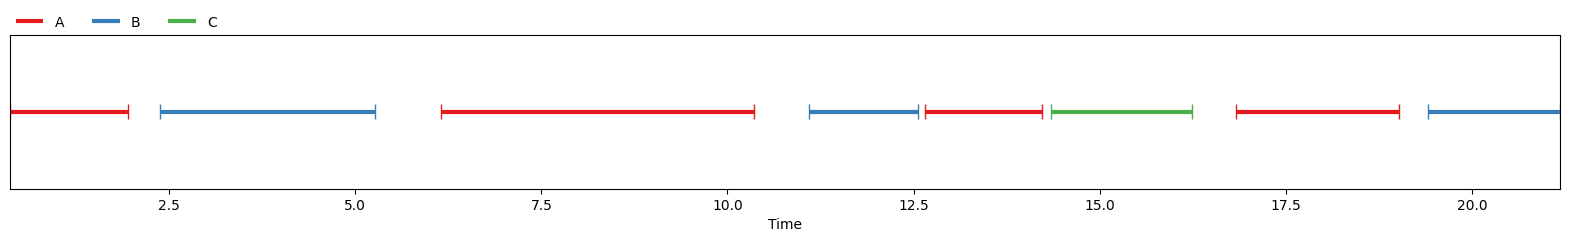

In [7]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(libritts_test(), **config.data.model_dump())
reference = format.labels_to_annotation(labels)
play(audio)


# Build the prompt version as the model could be choosing different speakers

nlabels = model.generate(audio[None], temperature=1, max_steps=(len(labels))*3, top_p=.5)
print("\n".join([str(n) for n in nlabels]))

for l in nlabels:
    l[2] = l[2]+ "'"

hypothesis = visualise_annotation(labels+nlabels)

[11.239192962646484, 12.708932876586914, 'B']
[14.438039779663086, 16.426511764526367, 'A']
[17.031700134277344, 19.193082809448242, 'B']
[6.397694110870361, 10.547550201416016, 'C']
[0.518731951713562, 2.1613831520080566, 'A']
[12.795388221740723, 14.438039779663086, 'B']
[2.507204532623291, 5.446685791015625, 'B']
[19.538904190063477, 21.35446548461914, 'C']


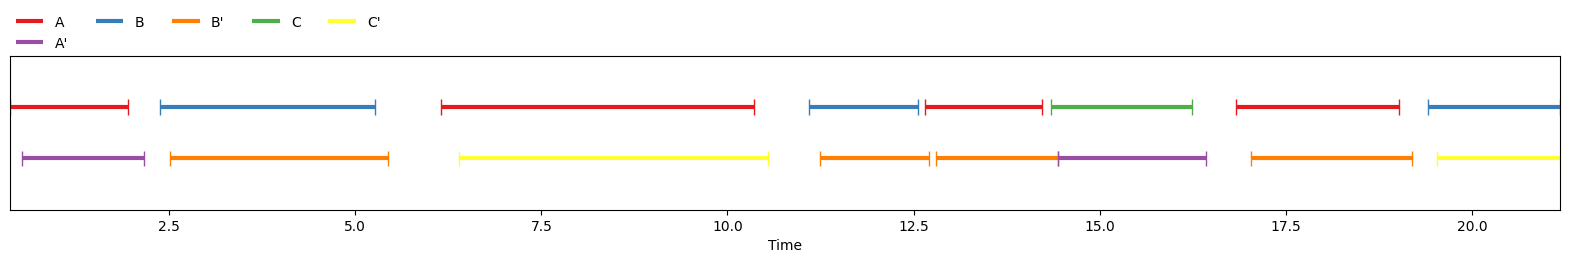

### Calculate Metrics with Pyannote


In [19]:
from pyannote.core import Annotation
from pyannote.metrics.diarization import DiarizationErrorRate

metric = DiarizationErrorRate()
metric(reference, hypothesis)

1.0131037779322372